In [ ]:
!pip install belief-propagation-ldpc

In [ ]:
from belief_propagation import BeliefPropagation, TannerGraph, bsc_llr
import numpy as np

# consider a parity check matrix
H = np.array([[1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
              [1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
              [0, 1, 0, 0, 1, 0, 0, 1, 1, 0],
              [0, 0, 1, 0, 0, 1, 0, 1, 0, 1],
              [0, 0, 0, 1, 0, 0, 1, 0, 1, 1]])
model = bsc_llr(0.1)
tg = TannerGraph.from_biadjacency_matrix(H, channel_model=model)
c = np.array([1, 1, 0, 0, 1, 0, 0, 0, 0, 1])
bp = BeliefPropagation(tg, H, max_iter=10)
estimate, llr, decode_success = bp.decode(c)
print(c, estimate, llr, decode_success)

[1 1 0 0 1 0 0 0 0 1] [1 1 0 0 1 0 0 0 0 0] [-4.45897088 -4.45897088  2.19722458  2.19722458 -4.45897088  2.19722458
  2.19722458  2.19722458  2.19722458  0.06452172] True


**Figure 2** - Mismatch probability for MS, OMS, AMS and proposed algorithm replication


dc = 3
dc = 4
dc = 5
dc = 6
dc = 7
dc = 8
dc = 9
dc = 10


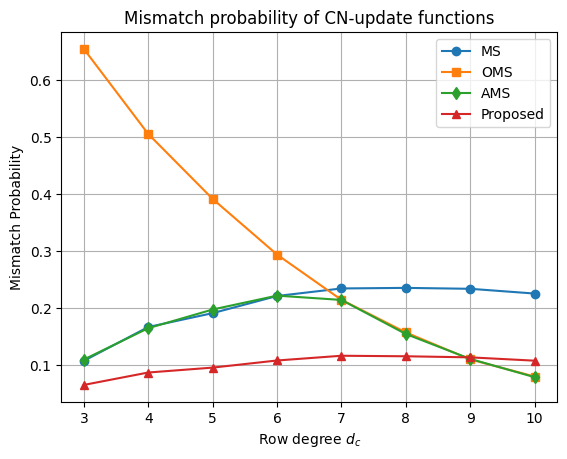

In [ ]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

# ---------- parameters ----------
q = 4
Q = 2**(q-1) - 1
dc_range = range(3,11)

SAMPLES = 20000   # Monte Carlo samples


# ---------- φ(x) ----------
def phi(x):
    return -np.log(np.tanh(x/2 + 1e-12))


# ---------- BP ----------
def cn_bp(beta, n):

    others = [beta[i] for i in range(len(beta)) if i != n]

    val = sum(phi(abs(x)) for x in others)
    return phi(val)


# ---------- MS ----------
def cn_ms(beta, n):

    others = [abs(beta[i]) for i in range(len(beta)) if i != n]
    return min(others)


# ---------- OMS ----------
def cn_oms(beta, n, lam=1):

    others = [abs(beta[i]) for i in range(len(beta)) if i != n]
    return max(min(others) - lam, 0)


# ---------- AMS ----------
def cn_ams(beta, n, is_core):

    others = [abs(beta[i]) for i in range(len(beta)) if i != n]
    m = min(others)

    if is_core:
        return max(m - 1, 0)
    else:
        return m


# ---------- Proposed ----------
def cn_proposed(beta, n):

    mags = [abs(x) for x in beta]

    idx = np.argsort(mags)

    min1 = mags[idx[0]]
    min2 = mags[idx[1]]

    if n == idx[0]:
        return min2

    elif n == idx[1]:
        return min1

    else:
        if min1 > 0 and min1 == min2:
            return max(min1 - 1, 0)
        else:
            return min1


# ---------- mismatch probability ----------
def mismatch_probability(dc, method):

    mismatch = 0
    total = 0

    is_core = dc >= 7

    for _ in range(SAMPLES):

        beta = np.random.randint(0, Q+1, dc)

        for n in range(dc):

            bp = cn_bp(beta, n)

            if method == "MS":
                est = cn_ms(beta, n)

            elif method == "OMS":
                est = cn_oms(beta, n)

            elif method == "AMS":
                est = cn_ams(beta, n, is_core)

            elif method == "PROP":
                est = cn_proposed(beta, n)

            if round(bp) != round(est):
                mismatch += 1

            total += 1

    return mismatch / total


# ---------- run ----------
ms_prob = []
oms_prob = []
ams_prob = []
prop_prob = []

for dc in dc_range:

    print("dc =", dc)

    ms_prob.append(mismatch_probability(dc,"MS"))
    oms_prob.append(mismatch_probability(dc,"OMS"))
    ams_prob.append(mismatch_probability(dc,"AMS"))
    prop_prob.append(mismatch_probability(dc,"PROP"))


# ---------- plot ----------
plt.figure()

plt.plot(dc_range, ms_prob, marker='o', label="MS")
plt.plot(dc_range, oms_prob, marker='s', label="OMS")
plt.plot(dc_range, ams_prob, marker='d', label="AMS")
plt.plot(dc_range, prop_prob, marker='^', label="Proposed")

plt.xlabel("Row degree $d_c$")
plt.ylabel("Mismatch Probability")
plt.title("Mismatch probability of CN-update functions")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
!pip install tk

In [ ]:
!pip install pyldpc sionna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.4/520.4 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.2 MB/s eta 0:00:00
  Created whe

**Figure - 3,4,5** - replication of frame error rates for the given quantised bits configurations

H matrix shape: (3024, 3744)
Lifting factor Z: 72


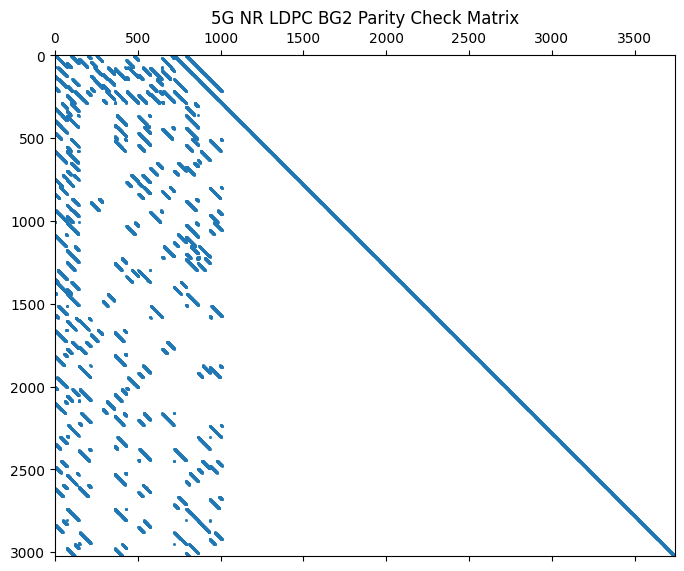

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sionna.phy.fec.ldpc.encoding import LDPC5GEncoder

k = 520
n = 2600

encoder = LDPC5GEncoder(k=k, n=n, bg="bg2")

# Get parity-check matrix
H_sparse = encoder.pcm          # csr_matrix
H = H_sparse.toarray()          # convert to numpy array

print("H matrix shape:", H.shape)
print("Lifting factor Z:", encoder.z)

plt.figure(figsize=(8,8))
plt.spy(H_sparse, markersize=1)  # plotting sparse matrix directly is faster
plt.title("5G NR LDPC BG2 Parity Check Matrix")
plt.show()

In [ ]:
bg2_entries = [
    # ===== rows 0–7 (Initial Data) =====
    (0, 0, [9, 174, 0, 72, 3, 156, 143, 145]),
    (0, 1, [117, 97, 0, 110, 26, 143, 19, 131]),
    (0, 2, [204, 166, 0, 23, 53, 14, 176, 71]),
    (0, 3, [26, 66, 0, 181, 35, 3, 165, 21]),
    (0, 6, [189, 71, 0, 95, 115, 40, 196, 23]),
    (0, 9, [205, 172, 0, 8, 127, 123, 13, 112]),
    (0, 10, [0, 0, 0, 1, 0, 0, 0, 1]),
    (0, 11, [0, 0, 0, 0, 0, 0, 0, 0]),
    (1, 0, [167, 27, 137, 53, 19, 17, 18, 142]),
    (1, 3, [166, 36, 124, 156, 94, 65, 27, 174]),
    (1, 4, [253, 48, 0, 115, 104, 63, 3, 183]),
    (1, 5, [125, 92, 0, 156, 66, 1, 102, 27]),
    (1, 6, [226, 31, 88, 115, 84, 55, 185, 96]),
    (1, 7, [156, 187, 0, 200, 98, 37, 17, 23]),
    (1, 8, [224, 185, 0, 29, 69, 171, 14, 9]),
    (1, 9, [252, 3, 55, 31, 50, 133, 180, 167]),
    (1, 11, [0, 0, 0, 0, 0, 0, 0, 0]),
    (1, 12, [0, 0, 0, 0, 0, 0, 0, 0]),
    (2, 0, [81, 25, 20, 152, 95, 98, 126, 74]),
    (2, 1, [114, 114, 94, 131, 106, 168, 163, 31]),
    (2, 3, [44, 117, 99, 46, 92, 107, 47, 3]),
    (2, 4, [52, 110, 9, 191, 110, 82, 183, 53]),
    (2, 8, [240, 114, 108, 91, 111, 142, 132, 155]),
    (2, 10, [1, 1, 1, 0, 1, 1, 1, 0]),
    (2, 12, [0, 0, 0, 0, 0, 0, 0, 0]),
    (2, 13, [0, 0, 0, 0, 0, 0, 0, 0]),
    (3, 1, [8, 136, 38, 185, 120, 53, 36, 239]),
    (3, 2, [58, 175, 15, 6, 121, 174, 48, 171]),
    (3, 4, [158, 113, 102, 36, 22, 174, 18, 95]),
    (3, 5, [104, 72, 146, 124, 4, 127, 111, 110]),
    (3, 6, [209, 123, 12, 124, 73, 17, 203, 159]),
    (3, 7, [54, 118, 57, 110, 49, 89, 3, 199]),
    (3, 8, [18, 28, 53, 156, 128, 17, 191, 43]),
    (3, 9, [128, 186, 46, 133, 79, 105, 160, 75]),
    (3, 10, [0, 0, 0, 1, 0, 0, 0, 1]),
    (3, 13, [0, 0, 0, 0, 0, 0, 0, 0]),
    (4, 0, [179, 72, 0, 200, 42, 86, 43, 29]),
    (4, 1, [214, 74, 136, 16, 24, 67, 27, 140]),
    (4, 11, [71, 29, 157, 101, 51, 83, 117, 180]),
    (4, 14, [0, 0, 0, 0, 0, 0, 0, 0]),
    (5, 0, [231, 10, 0, 185, 40, 79, 136, 121]),
    (5, 1, [41, 44, 131, 138, 140, 84, 49, 41]),
    (5, 5, [194, 121, 142, 170, 84, 35, 36, 169]),
    (5, 7, [159, 80, 141, 219, 137, 103, 132, 88]),
    (5, 11, [103, 48, 64, 193, 71, 60, 62, 207]),
    (5, 15, [0, 0, 0, 0, 0, 0, 0, 0]),
    (6, 0, [155, 129, 0, 123, 109, 47, 7, 137]),
    (6, 5, [228, 92, 124, 55, 87, 154, 34, 72]),
    (6, 7, [45, 100, 99, 31, 107, 10, 198, 172]),
    (6, 9, [28, 49, 45, 222, 133, 155, 168, 124]),
    (6, 11, [158, 184, 148, 209, 139, 29, 12, 56]),
    (6, 16, [0, 0, 0, 0, 0, 0, 0, 0]),
    (7, 1, [129, 80, 0, 103, 97, 48, 163, 86]),
    (7, 5, [147, 186, 45, 13, 135, 125, 78, 186]),
    (7, 7, [140, 16, 148, 105, 35, 24, 143, 87]),
    (7, 11, [3, 102, 96, 150, 108, 47, 107, 172]),
    (7, 13, [116, 143, 78, 181, 65, 55, 58, 154]),
    (7, 17, [0, 0, 0, 0, 0, 0, 0, 0]),

    # ===== rows 8–15 =====
    (8, 0, [142, 118, 0, 147, 70, 53, 101, 176]),
    (8, 1, [94, 70, 65, 43, 69, 31, 177, 169]),
    (8, 12, [230, 152, 87, 152, 88, 161, 22, 225]),
    (8, 18, [0, 0, 0, 0, 0, 0, 0, 0]),
    (9, 1, [203, 28, 0, 2, 97, 104, 186, 167]),
    (9, 8, [205, 132, 97, 30, 40, 142, 27, 238]),
    (9, 10, [61, 185, 51, 184, 24, 99, 205, 48]),
    (9, 11, [247, 178, 85, 83, 49, 64, 81, 68]),
    (9, 19, [0, 0, 0, 0, 0, 0, 0, 0]),
    (10, 0, [11, 59, 0, 174, 46, 111, 125, 38]),
    (10, 1, [185, 104, 17, 150, 41, 25, 60, 217]),
    (10, 6, [0, 22, 156, 8, 101, 174, 177, 208]),
    (10, 7, [117, 52, 20, 56, 96, 23, 51, 232]),
    (10, 20, [0, 0, 0, 0, 0, 0, 0, 0]),
    (11, 0, [11, 32, 0, 99, 28, 91, 39, 178]),
    (11, 7, [236, 92, 7, 138, 30, 175, 29, 214]),
    (11, 9, [210, 174, 4, 110, 116, 24, 35, 168]),
    (11, 13, [56, 154, 2, 99, 64, 141, 8, 51]),
    (11, 21, [0, 0, 0, 0, 0, 0, 0, 0]),
    (12, 1, [63, 39, 0, 46, 33, 122, 18, 124]),
    (12, 3, [111, 93, 113, 217, 122, 11, 155, 122]),
    (12, 11, [14, 11, 48, 109, 131, 4, 49, 72]),
    (12, 22, [0, 0, 0, 0, 0, 0, 0, 0]),
    (13, 0, [83, 49, 0, 37, 76, 29, 32, 48]),
    (13, 1, [2, 125, 112, 113, 37, 91, 53, 57]),
    (13, 8, [38, 35, 102, 143, 62, 27, 95, 167]),
    (13, 13, [222, 166, 26, 140, 47, 127, 186, 219]),
    (13, 23, [0, 0, 0, 0, 0, 0, 0, 0]),
    (14, 1, [115, 19, 0, 36, 143, 11, 91, 82]),
    (14, 6, [145, 118, 138, 95, 51, 145, 20, 232]),
    (14, 11, [3, 21, 57, 40, 130, 8, 52, 204]),
    (14, 13, [232, 163, 27, 116, 97, 166, 109, 162]),
    (14, 24, [0, 0, 0, 0, 0, 0, 0, 0]),
    (15, 0, [51, 68, 0, 116, 139, 137, 174, 38]),
    (15, 10, [175, 63, 73, 200, 96, 103, 108, 217]),
    (15, 11, [213, 81, 99, 110, 128, 40, 102, 157]),
    (15, 25, [0, 0, 0, 0, 0, 0, 0, 0]),

    # ===== rows 16–23 =====
    (16, 1, [203, 87, 0, 75, 48, 78, 125, 170]),
    (16, 9, [142, 177, 79, 158, 9, 158, 31, 23]),
    (16, 11, [8, 135, 111, 134, 28, 17, 54, 175]),
    (16, 12, [242, 64, 143, 97, 8, 165, 176, 202]),
    (16, 26, [0, 0, 0, 0, 0, 0, 0, 0]),
    (17, 1, [254, 158, 0, 48, 120, 134, 57, 196]),
    (17, 5, [124, 23, 24, 132, 43, 23, 201, 173]),
    (17, 11, [114, 9, 109, 206, 65, 62, 142, 195]),
    (17, 12, [64, 6, 18, 2, 42, 163, 35, 218]),
    (17, 27, [0, 0, 0, 0, 0, 0, 0, 0]),
    (18, 0, [220, 186, 0, 68, 17, 173, 129, 128]),
    (18, 6, [194, 6, 18, 16, 106, 31, 203, 211]),
    (18, 7, [50, 46, 86, 156, 142, 22, 140, 210]),
    (18, 28, [0, 0, 0, 0, 0, 0, 0, 0]),
    (19, 0, [87, 58, 0, 35, 79, 13, 110, 39]),
    (19, 1, [20, 42, 158, 138, 28, 135, 124, 84]),
    (19, 10, [185, 156, 154, 86, 41, 145, 52, 88]),
    (19, 29, [0, 0, 0, 0, 0, 0, 0, 0]),
    (20, 1, [26, 76, 0, 6, 2, 128, 196, 117]),
    (20, 4, [105, 61, 148, 20, 103, 52, 35, 227]),
    (20, 11, [29, 153, 104, 141, 78, 173, 114, 6]),
    (20, 30, [0, 0, 0, 0, 0, 0, 0, 0]),
    (21, 0, [76, 157, 0, 80, 91, 156, 10, 238]),
    (21, 8, [42, 175, 17, 43, 75, 166, 122, 13]),
    (21, 13, [210, 67, 33, 81, 81, 40, 23, 11]),
    (21, 31, [0, 0, 0, 0, 0, 0, 0, 0]),
    (22, 1, [222, 20, 0, 49, 54, 18, 202, 195]),
    (22, 2, [63, 52, 4, 1, 132, 163, 126, 44]),
    (22, 32, [0, 0, 0, 0, 0, 0, 0, 0]),
    (23, 0, [23, 106, 0, 156, 68, 110, 52, 5]),
    (23, 3, [235, 86, 75, 54, 115, 132, 170, 94]),
    (23, 5, [238, 95, 158, 134, 56, 150, 13, 111]),
    (23, 33, [0, 0, 0, 0, 0, 0, 0, 0]),

    # ===== rows 24–31 =====
    (24, 1, [46, 182, 0, 153, 30, 113, 113, 81]),
    (24, 2, [139, 153, 69, 88, 42, 108, 161, 19]),
    (24, 9, [8, 64, 87, 63, 101, 61, 88, 130]),
    (24, 34, [0, 0, 0, 0, 0, 0, 0, 0]),
    (25, 0, [228, 45, 0, 211, 128, 72, 197, 66]),
    (25, 5, [156, 21, 65, 94, 63, 136, 194, 95]),
    (25, 35, [0, 0, 0, 0, 0, 0, 0, 0]),
    (26, 2, [29, 67, 0, 90, 142, 36, 164, 146]),
    (26, 7, [143, 137, 100, 6, 28, 38, 172, 66]),
    (26, 12, [160, 55, 13, 221, 100, 53, 49, 190]),
    (26, 13, [122, 85, 7, 6, 133, 145, 161, 86]),
    (26, 36, [0, 0, 0, 0, 0, 0, 0, 0]),
    (27, 0, [8, 103, 0, 27, 13, 42, 168, 64]),
    (27, 6, [151, 50, 32, 118, 10, 104, 193, 181]),
    (27, 37, [0, 0, 0, 0, 0, 0, 0, 0]),
    (28, 1, [98, 70, 0, 216, 106, 64, 14, 7]),
    (28, 2, [101, 111, 126, 212, 77, 24, 186, 144]),
    (28, 5, [135, 168, 110, 193, 43, 149, 46, 16]),
    (28, 38, [0, 0, 0, 0, 0, 0, 0, 0]),
    (29, 0, [18, 110, 0, 108, 133, 139, 50, 25]),
    (29, 4, [28, 17, 154, 61, 25, 161, 27, 57]),
    (29, 39, [0, 0, 0, 0, 0, 0, 0, 0]),
    (30, 2, [71, 120, 0, 106, 87, 84, 70, 37]),
    (30, 5, [240, 154, 35, 44, 56, 173, 17, 139]),
    (30, 7, [9, 52, 51, 185, 104, 93, 50, 221]),
    (30, 9, [84, 56, 134, 176, 70, 29, 6, 17]),
    (30, 40, [0, 0, 0, 0, 0, 0, 0, 0]),
    (31, 1, [106, 3, 0, 147, 80, 117, 115, 201]),
    (31, 13, [1, 170, 20, 182, 139, 148, 189, 46]),
    (31, 41, [0, 0, 0, 0, 0, 0, 0, 0]),

    # ===== rows 32–41 =====
    (32, 0, [242, 84, 0, 108, 32, 116, 110, 179]),
    (32, 5, [44, 8, 20, 21, 89, 73, 0, 14]),
    (32, 12, [166, 17, 122, 110, 71, 142, 163, 116]),
    (32, 42, [0, 0, 0, 0, 0, 0, 0, 0]),
    (33, 2, [132, 165, 0, 71, 135, 105, 163, 46]),
    (33, 7, [164, 179, 88, 12, 6, 137, 173, 2]),
    (33, 10, [235, 124, 13, 109, 2, 29, 179, 106]),
    (33, 43, [0, 0, 0, 0, 0, 0, 0, 0]),
    (34, 0, [147, 173, 0, 29, 37, 11, 197, 184]),
    (34, 12, [85, 177, 19, 201, 25, 41, 191, 135]),
    (34, 13, [36, 12, 78, 69, 114, 162, 193, 141]),
    (34, 44, [0, 0, 0, 0, 0, 0, 0, 0]),
    (35, 1, [57, 77, 0, 91, 60, 126, 157, 85]),
    (35, 5, [40, 184, 157, 165, 137, 152, 167, 225]),
    (35, 11, [63, 18, 6, 55, 93, 172, 181, 175]),
    (35, 45, [0, 0, 0, 0, 0, 0, 0, 0]),
    (36, 0, [140, 25, 0, 1, 121, 73, 197, 178]),
    (36, 2, [38, 151, 63, 175, 129, 154, 167, 112]),
    (36, 7, [154, 170, 82, 83, 26, 129, 179, 106]),
    (36, 46, [0, 0, 0, 0, 0, 0, 0, 0]),
    (37, 10, [219, 37, 0, 40, 97, 167, 181, 154]),
    (37, 13, [151, 31, 144, 12, 38, 38, 193, 114]),
    (37, 47, [0, 0, 0, 0, 0, 0, 0, 0]),
    (38, 1, [31, 84, 0, 37, 1, 112, 157, 42]),
    (38, 5, [66, 151, 93, 97, 70, 7, 173, 41]),
    (38, 11, [38, 190, 19, 46, 1, 19, 191, 105]),
    (38, 48, [0, 0, 0, 0, 0, 0, 0, 0]),
    (39, 0, [239, 93, 0, 106, 119, 109, 181, 167]),
    (39, 7, [172, 132, 24, 181, 32, 6, 157, 45]),
    (39, 12, [34, 57, 138, 154, 142, 105, 173, 189]),
    (39, 49, [0, 0, 0, 0, 0, 0, 0, 0]),
    (40, 2, [0, 103, 0, 98, 6, 160, 193, 78]),
    (40, 10, [75, 107, 36, 35, 73, 156, 163, 67]),
    (40, 13, [120, 163, 143, 36, 102, 82, 179, 180]),
    (40, 50, [0, 0, 0, 0, 0, 0, 0, 0]),
    (41, 1, [129, 147, 0, 120, 48, 132, 191, 53]),
    (41, 5, [229, 7, 2, 101, 47, 6, 197, 215]),
    (41, 11, [118, 60, 55, 81, 19, 8, 167, 230]),
    (41, 51, [0, 0, 0, 0, 0, 0, 0, 0])
]

(672, 832)


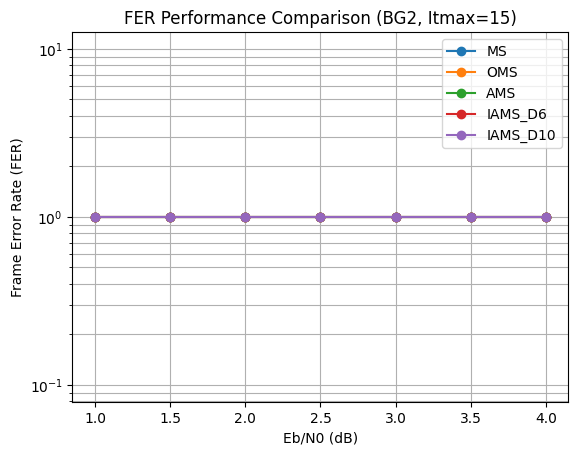

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np

# BG2 has 42 rows × 52 columns
BG2_base = -1 * np.ones((42, 52), dtype=int)

# Fill in entries
for row, col, shifts in bg2_entries:
    # For Z=52, the spec says use the 3rd element (index 2) of the list
    # Adjust index depending on your chosen Z
    shift_val = shifts[2]  # index for Z=52
    BG2_base[row, col] = shift_val if shift_val >= 0 else -1

def expand_bg(base_matrix, Z):
    M, N = base_matrix.shape
    H = np.zeros((M*Z, N*Z), dtype=int)
    I = np.eye(Z, dtype=int)

    for i in range(M):
        for j in range(N):
            val = base_matrix[i,j]
            if val == -1:
                block = np.zeros((Z,Z), dtype=int)
            else:
                block = np.roll(I, val % Z, axis=1)
            H[i*Z:(i+1)*Z, j*Z:(j+1)*Z] = block
    return H

Z = 16
H_bg2 = expand_bg(BG2_base, Z)
print(H_bg2.shape)  # (42*52, 52*52) = (2184, 2704)

def bpsk_modulate(bits):
    return 1 - 2*bits

def awgn_channel(x, snr_db):
    snr_linear = 10**(snr_db/10)
    sigma = np.sqrt(1/(2*snr_linear))
    noise = sigma * np.random.randn(len(x))
    return x + noise

def hard_decision(llr):
    return (llr < 0).astype(int)

def cn_update_ms(messages):
    # Standard min-sum
    sign = np.prod(np.sign(messages))
    min_val = np.min(np.abs(messages))
    return sign * min_val

def cn_update_oms(messages, offset=1):
    sign = np.prod(np.sign(messages))
    min_val = np.min(np.abs(messages)) - offset
    return sign * max(min_val, 0)

def cn_update_ams(messages, offset=1, is_core=True):
    # AMS: offset only for core checks
    sign = np.prod(np.sign(messages))
    min_val = np.min(np.abs(messages))
    if is_core:
        min_val = max(min_val - offset, 0)
    return sign * min_val

def cn_update_proposed(messages):
    # Proposed CN-update using min1 and min2
    abs_vals = np.abs(messages)
    idx = np.argsort(abs_vals)
    min1, min2 = abs_vals[idx[0]], abs_vals[idx[1]]
    sign = np.prod(np.sign(messages))
    if min1 > 0 and min1 == min2:
        offset = 1
    else:
        offset = 0
    return sign * max(min1 - offset, 0)

def cn_update_iams(messages, vn_degree, D=6):
    # If VN degree > D, use OMS instead of proposed
    if vn_degree > D:
        return cn_update_oms(messages, offset=1)
    else:
        return cn_update_proposed(messages)
def ldpc_decode(y, H, algo="MS", max_iter=15, D=6):
    N = H.shape[1]
    M = H.shape[0]
    app = y.copy()                     # APP vector
    alpha = np.zeros((M, N))           # CTV messages

    for it in range(max_iter):
        for m in range(M):             # process each CN layer
            vn_indices = np.where(H[m,:])[0]
            if vn_indices.size == 0:
                continue

            # Step 1: VN update
            beta = {n: app[n] - alpha[m,n] for n in vn_indices}

            # Step 2: CN update
            abs_vals = [abs(beta[n]) for n in vn_indices]
            min_val = np.min(abs_vals)
            for n in vn_indices:
                extrinsic = [beta[k] for k in vn_indices if k != n]
                sign = np.prod(np.sign(extrinsic))
                if algo == "MS":
                    ctv = sign * min_val
                elif algo == "OMS":
                    ctv = sign * max(min_val - 1, 0)
                elif algo == "AMS":
                    is_core = (m < 4)
                    ctv = sign * (max(min_val - 1, 0) if is_core else min_val)
                elif algo == "IAMS":
                    vn_degree = len(vn_indices)
                    if vn_degree > D:
                        ctv = sign * max(min_val - 1, 0)
                    else:
                        ctv = sign * min_val
                alpha[m,n] = ctv

            # Step 3: APP update
            for n in vn_indices:
                app[n] = beta[n] + alpha[m,n]

        decoded = (app < 0).astype(int)
        if np.all((H @ decoded) % 2 == 0):
            return decoded

    return (app < 0).astype(int)

def simulate_fer(H, algo, snr_db, num_frames=200, D=6, max_iter=15):
    N = H.shape[1]
    frame_errors = 0
    for _ in range(num_frames):
        bits = np.random.randint(0,2,N)
        x = bpsk_modulate(bits)
        y = awgn_channel(x, snr_db)
        decoded = ldpc_decode(y, H, algo=algo, max_iter=max_iter, D=D)
        if not np.array_equal(bits, decoded):
            frame_errors += 1
    return frame_errors / num_frames

# Example BG2 skeleton (replace with full spec for accuracy)
BG2 = np.random.randint(-1, 2, (42,52))  # placeholder
H = (BG2 != -1).astype(int)

snr_range = [1, 1.5, 2.0, 2.5, 3.0, 3.5, 4]
algos = ["MS","OMS","AMS"]
results = {algo: [] for algo in algos}
results["IAMS_D6"] = []
results["IAMS_D10"] = []

for snr in snr_range:
    for algo in algos:
        fer = simulate_fer(H_bg2, algo, snr, num_frames=10, max_iter=15)
        results[algo].append(fer)
    results["IAMS_D6"].append(simulate_fer(H_bg2, "IAMS", snr, num_frames=10, D=6, max_iter=15))
    results["IAMS_D10"].append(simulate_fer(H_bg2, "IAMS", snr, num_frames=10, D=10, max_iter=15))

plt.figure()
for algo in results:
    plt.semilogy(snr_range, results[algo], marker='o', label=algo)
plt.xlabel("Eb/N0 (dB)")
plt.ylabel("Frame Error Rate (FER)")
plt.title("FER Performance Comparison (BG2, Itmax=15)")
plt.legend()
plt.grid(True, which="both")
plt.show()


H shape: (2184, 2704)


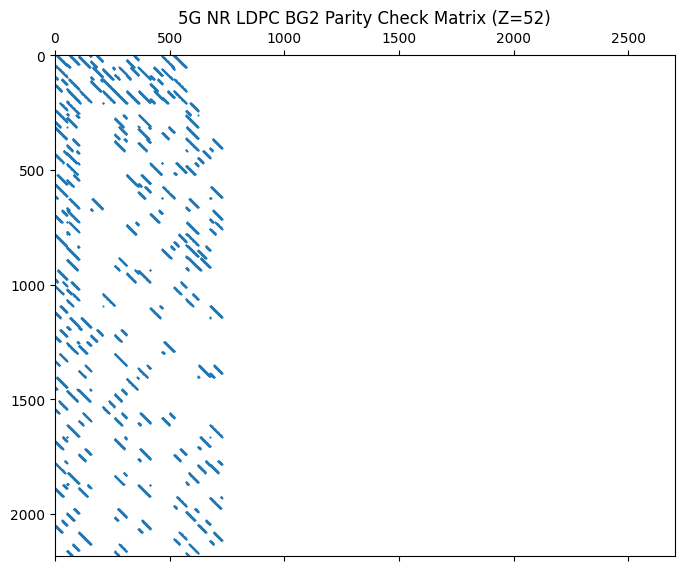

In [ ]:
import numpy as np

def circulant_perm(Z, shift):
    """
    Create ZxZ circulant permutation matrix with right shift
    """
    I = np.eye(Z, dtype=int)
    return np.roll(I, shift % Z, axis=1)

# BG2 dimensions
BG2_rows = 42
BG2_cols = 52

# lifting factor for the paper simulation
Z = 52

# initialize full H matrix
H = np.zeros((BG2_rows*Z, BG2_cols*Z), dtype=int)

# choose lifting set index (0..7)
LS_index = 0

for row, col, shifts in bg2_entries:

    shift = shifts[LS_index]

    # skip zero blocks
    if shift == 0 and all(v == 0 for v in shifts):
        continue

    block = circulant_perm(Z, shift)

    r_start = row * Z
    r_end   = (row + 1) * Z

    c_start = col * Z
    c_end   = (col + 1) * Z

    H[r_start:r_end, c_start:c_end] = block

print("H shape:", H.shape)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.spy(H, markersize=0.5)
plt.title("5G NR LDPC BG2 Parity Check Matrix (Z=52)")
plt.show()

check_nodes = []
var_nodes = [[] for _ in range(H.shape[1])]

for i in range(H.shape[0]):
    cols = np.where(H[i] == 1)[0]
    check_nodes.append(cols)

    for c in cols:
        var_nodes[c].append(i)